In [1]:
import numpy as np
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving compr_data.zip to compr_data.zip


In [3]:
!unzip ./compr_data.zip

Archive:  ./compr_data.zip
  inflating: train.csv               


In [4]:
data = pd.read_csv('./train.csv')

In [ ]:
data.head(10)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,0,Male,21,1,35.0,0,1-2 Year,Yes,65101.0,124.0,187,0
1,1,Male,43,1,28.0,0,> 2 Years,Yes,58911.0,26.0,288,1
2,2,Female,25,1,14.0,1,< 1 Year,No,38043.0,152.0,254,0
3,3,Female,35,1,1.0,0,1-2 Year,Yes,2630.0,156.0,76,0
4,4,Female,36,1,15.0,1,1-2 Year,No,31951.0,152.0,294,0
5,5,Female,31,1,47.0,1,< 1 Year,No,28150.0,152.0,197,0
6,6,Male,23,1,45.0,1,< 1 Year,No,27128.0,152.0,190,0
7,7,Female,47,1,8.0,0,1-2 Year,Yes,40659.0,26.0,262,1
8,8,Female,26,1,28.0,1,< 1 Year,No,31639.0,152.0,36,0
9,9,Female,66,1,11.0,0,1-2 Year,Yes,2630.0,26.0,125,0


In [ ]:
print(f'Train share: {5000000 / len(data):.3f}')

Train share: 0.435


In [5]:
data_train = data.head(5000000)

In [6]:
data_test = data.tail(len(data) - len(data_train))

In [ ]:
len(data_test) + len(data_train) == len(data)

True

In [7]:
import sys
import os

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

Останемся себе верны, просто скопируем код:

In [9]:
def fit_preprocessor(train_df):
    """
    Рассчитывает все параметры препроцессинга на обучающих данных
    """
    preprocessor_params = {}

    #print("Обучение препроцессора на train данных...")

    # 1. Медианы для заполнения пропусков в числовых признаках
    numeric_cols = train_df.select_dtypes(include=[np.number]).columns
    medians = {}
    for col in numeric_cols:
        if col not in ['Response']:  # Исключаем целевую переменную
            medians[col] = train_df[col].median()
    preprocessor_params['medians'] = medians
    #print(f"  Рассчитаны медианы для {len(medians)} признаков")

    # 2. LabelEncoders для категориальных признаков
    label_encoders = {}

    # Для бинарных категориальных признаков
    binary_cols = ['Gender', 'Vehicle_Damage']
    for col in binary_cols:
        if col in train_df.columns:
            le = LabelEncoder()
            # Преобразуем в строку и обучаем
            train_df[col] = train_df[col].astype(str)
            le.fit(train_df[col])
            label_encoders[col] = le
            #print(f"  Обучен LabelEncoder для {col}")

    # Для Vehicle_Age - создаем маппинг
    if 'Vehicle_Age' in train_df.columns:
        vehicle_age_mapping = {
            '< 1 Year': 0,
            '1-2 Year': 1,
            '> 2 Years': 2
        }
        preprocessor_params['vehicle_age_mapping'] = vehicle_age_mapping
        #print("  Создан маппинг для Vehicle_Age")

    preprocessor_params['label_encoders'] = label_encoders

    # 3. Квантили для удаления выбросов
    if 'Annual_Premium' in train_df.columns:
        premium_q99 = train_df['Annual_Premium'].quantile(0.999)
        preprocessor_params['premium_q99'] = premium_q99
        #print(f"  Рассчитан 99.9% квантиль для Annual_Premium: {premium_q99}")

    # 4. Границы для Age групп
    if 'Age' in train_df.columns:
        age_bins = [18, 25, 35, 50, 65, 100]
        preprocessor_params['age_bins'] = age_bins
        #print(f"  Определены границы Age групп: {age_bins}")

    # 5. Квантили для Premium_Group
    if 'Annual_Premium' in train_df.columns:
        try:
            # Определяем квантили на train
            premium_quantiles = np.percentile(train_df['Annual_Premium'], [0, 20, 40, 60, 80, 100])
            preprocessor_params['premium_quantiles'] = premium_quantiles.tolist()
            #print(f"  Рассчитаны квантили для Premium_Group: {premium_quantiles}")
        except Exception as e:
            print(f"  Не удалось рассчитать квантили для Premium_Group: {e}")

    # 6. StandardScaler для числовых признаков
    numeric_features = ['Age', 'Annual_Premium', 'Vintage', 'Region_Code', 'Policy_Sales_Channel']
    numeric_features = [col for col in numeric_features if col in train_df.columns]

    if numeric_features:
        scaler = StandardScaler()
        # Преобразуем в float перед обучением
        train_numeric = train_df[numeric_features].astype('float64')
        scaler.fit(train_numeric)
        preprocessor_params['scaler'] = scaler
        preprocessor_params['numeric_features'] = numeric_features
        #print(f"  Обучен StandardScaler для признаков: {numeric_features}")

    return preprocessor_params


# Функция для применения препроцессора (к train и test)
def apply_preprocessor(df, preprocessor_params, is_train=False):
    """
    Применяет параметры препроцессора к данным
    is_train: True если это обучающие данные (для них удаляем выбросы)
    """
    df_processed = df.copy()

    # 1. Заполнение пропусков медианами (из train)
    if 'medians' in preprocessor_params:
        for col, median_val in preprocessor_params['medians'].items():
            if col in df_processed.columns:
                if df_processed[col].isnull().sum() > 0:
                    df_processed.loc[df_processed[col].isnull(), col] = median_val
                    #if is_train:
                        #print(f"  Заполнено пропусков в {col}: {df_processed[col].isnull().sum()}")

    # 2. Кодирование категориальных признаков
    if 'label_encoders' in preprocessor_params:
        for col, le in preprocessor_params['label_encoders'].items():
            if col in df_processed.columns:
                # Преобразуем в строку и применяем кодировку
                df_processed[col] = df_processed[col].astype(str)
                # Используем transform, а не fit_transform!
                try:
                    df_processed[col] = le.transform(df_processed[col])
                except ValueError as e:
                    # Если встретились новые значения в тесте, кодируем как -1
                    #print(f"  Предупреждение: новые значения в {col}, кодируем как -1")
                    # Создаем маппинг известных значений
                    known_values = set(le.classes_)

                    # Функция для преобразования
                    def encode_value(x):
                        return le.transform([x])[0] if x in known_values else -1

                    df_processed[col] = df_processed[col].apply(encode_value)

    # 3. Кодирование Vehicle_Age
    if 'vehicle_age_mapping' in preprocessor_params and 'Vehicle_Age' in df_processed.columns:
        vehicle_age_mapping = preprocessor_params['vehicle_age_mapping']
        df_processed['Vehicle_Age'] = df_processed['Vehicle_Age'].map(vehicle_age_mapping)
        # Заполняем пропуски значением 1 (самое частое)
        if df_processed['Vehicle_Age'].isnull().sum() > 0:
            df_processed.loc[df_processed['Vehicle_Age'].isnull(), 'Vehicle_Age'] = 1

    # 4. Обработка Region_Code и Policy_Sales_Channel
    for col in ['Region_Code', 'Policy_Sales_Channel']:
        if col in df_processed.columns:
            # Преобразуем в строку и извлекаем числа
            df_processed[col] = df_processed[col].astype(str)
            df_processed[col] = df_processed[col].str.extract(r'(\d+)')
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
            # Заполняем пропуски медианой из train
            if col in preprocessor_params.get('medians', {}):
                median_val = preprocessor_params['medians'][col]
                df_processed.loc[df_processed[col].isnull(), col] = median_val

    # 5. Удаление выбросов (ТОЛЬКО train!)
    if is_train and 'premium_q99' in preprocessor_params and 'Annual_Premium' in df_processed.columns:
        original_len = len(df_processed)
        premium_q99 = preprocessor_params['premium_q99']
        mask = df_processed['Annual_Premium'] <= premium_q99
        df_processed = df_processed[mask].copy()
        removed_count = original_len - len(df_processed)
        #if removed_count > 0:
            #print(f"  Удалено выбросов из Annual_Premium: {removed_count} строк")

    # 6. Обработка Age (только на train)
    if is_train and 'Age' in df_processed.columns:
        original_len = len(df_processed)
        age_mask = (df_processed['Age'] >= 18) & (df_processed['Age'] <= 100)
        df_processed = df_processed[age_mask].copy()
        removed_count = original_len - len(df_processed)
        #if removed_count > 0:
            #print(f"  Удалено некорректных значений Age: {removed_count} строк")

    # 7. Создание новых признаков
    # Age_Group
    if 'age_bins' in preprocessor_params and 'Age' in df_processed.columns:
        age_bins = preprocessor_params['age_bins']
        df_processed['Age_Group'] = pd.cut(df_processed['Age'],
                                           bins=age_bins,
                                           labels=[0, 1, 2, 3, 4],
                                           include_lowest=True)
        df_processed['Age_Group'] = df_processed['Age_Group'].astype('float64')

    # Premium_Group (используем квантили из train)
    if 'premium_quantiles' in preprocessor_params and 'Annual_Premium' in df_processed.columns:
        premium_quantiles = preprocessor_params['premium_quantiles']
        try:
            df_processed['Premium_Group'] = pd.cut(df_processed['Annual_Premium'],
                                                   bins=premium_quantiles,
                                                   labels=[0, 1, 2, 3, 4],
                                                   include_lowest=True)
            df_processed['Premium_Group'] = df_processed['Premium_Group'].astype('float64')
        except Exception as e:
            print(f"  Не удалось создать Premium_Group: {e}")

    # 8. Удаление ненужных столбцов, id не нужен для обучения
    columns_to_drop = ['id']
    for col in columns_to_drop:
        if col in df_processed.columns:
            df_processed = df_processed.drop(columns=[col])

    # 9. Нормализация числовых признаков
    if 'scaler' in preprocessor_params and 'numeric_features' in preprocessor_params:
        scaler = preprocessor_params['scaler']
        numeric_features = preprocessor_params['numeric_features']

        # Преобразуем в float64
        for col in numeric_features:
            if col in df_processed.columns:
                df_processed[col] = df_processed[col].astype('float64')

        # Применяем скаляр (transform, не fit_transform!)
        normalized_array = scaler.transform(df_processed[numeric_features])
        normalized_df = pd.DataFrame(normalized_array,
                                     columns=numeric_features,
                                     index=df_processed.index)

        for col in numeric_features:
            df_processed[col] = normalized_df[col]

    return df_processed

In [10]:
preprocessor_params = fit_preprocessor(data_train)

/tmp/ipython-input-1654215821.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[col] = train_df[col].astype(str)
/tmp/ipython-input-1654215821.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[col] = train_df[col].astype(str)


In [11]:
train_processed = apply_preprocessor(data_train, preprocessor_params, is_train=True)

In [12]:
test_processed = apply_preprocessor(data_test, preprocessor_params, is_train=False)

In [13]:
from sklearn.metrics import classification_report

In [14]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.3 MB/s eta 0:00:00


In [15]:
from catboost import CatBoostClassifier

In [16]:
categorical_features = ['Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Age_Group', 'Premium_Group']

In [17]:
X_train = train_processed.drop(['Response'], axis=1)
y_train = train_processed['Response']

In [18]:
X_test = test_processed.drop(['Response'], axis=1)
y_test = test_processed['Response']

In [32]:
X_train['Age_Group'] = X_train['Age_Group'].astype(int)
X_test['Age_Group'] = X_test['Age_Group'].astype(int)

In [33]:
X_train['Premium_Group'] = X_train['Premium_Group'].astype(int)
X_test['Premium_Group'] = X_test['Premium_Group'].astype(int)

Параметры, подобранные в Colab:

In [22]:
cb_classifier = CatBoostClassifier(task_type='GPU', rsm=1, random_strength=1, bootstrap_type='Bernoulli', l2_leaf_reg=5, grow_policy='SymmetricTree', depth=8, subsample=0.8, learning_rate=0.03, cat_features=categorical_features, auto_class_weights='Balanced', iterations=2000, early_stopping_rounds=100)

In [23]:
cb_classifier.fit(X_train, y_train, verbose=50)

0:	learn: 0.6644263	total: 530ms	remaining: 17m 40s
50:	learn: 0.4238339	total: 29.4s	remaining: 18m 41s
100:	learn: 0.4151894	total: 53.2s	remaining: 16m 40s
150:	learn: 0.4121959	total: 1m 19s	remaining: 16m 11s
200:	learn: 0.4104897	total: 1m 45s	remaining: 15m 42s
250:	learn: 0.4091753	total: 2m 7s	remaining: 14m 45s
300:	learn: 0.4081325	total: 2m 28s	remaining: 13m 59s
350:	learn: 0.4072905	total: 2m 50s	remaining: 13m 19s
400:	learn: 0.4065061	total: 3m 12s	remaining: 12m 48s
450:	learn: 0.4058232	total: 3m 34s	remaining: 12m 16s
500:	learn: 0.4052106	total: 3m 56s	remaining: 11m 47s
550:	learn: 0.4046955	total: 4m 18s	remaining: 11m 19s
600:	learn: 0.4042611	total: 4m 40s	remaining: 10m 52s
650:	learn: 0.4038313	total: 5m 1s	remaining: 10m 25s
700:	learn: 0.4034557	total: 5m 23s	remaining: 9m 59s
750:	learn: 0.4031305	total: 5m 44s	remaining: 9m 33s
800:	learn: 0.4028344	total: 6m 6s	remaining: 9m 8s
850:	learn: 0.4025708	total: 6m 27s	remaining: 8m 43s
900:	learn: 0.4023166	to

In [ ]:
print(classification_report(y_train, cb_classifier.predict(X_train)))

Оценка на Test:

In [27]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

In [28]:
import matplotlib.pyplot as plt

In [29]:
def plot_roc_pr_curves(y_scores, y_test, model_name):
    """
        Plots ROC and PR curves by y_scores (if possiable predictions
        probabilities, otherwise somewhat measure of confidene).
        Model name used for plots
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    #ROC curve and AUC-ROC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    ax1.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random classifier')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve - {model_name}')
    ax1.legend(loc="lower right")
    ax1.grid(True, alpha=0.3)

    #PR curve and AUC-PR
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = average_precision_score(y_test, y_scores)

    ax2.plot(recall, precision, color='green', lw=2,
             label=f'PR curve (AUC = {pr_auc:.3f})')

    #Line for random classifier
    random_precision = len(y_test[y_test == 1]) / len(y_test)
    ax2.axhline(y=random_precision, color='red', linestyle='--',
                label=f'Random classifier (AP = {random_precision:.3f})')

    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'Precision-Recall Curve - {model_name}')
    ax2.legend(loc="lower left")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return roc_auc, pr_auc

def calculate_auc_scores(y_scores, y_test):
    """
        Calculates AUC-ROC and AUC-PR
    """

    #AUC-ROC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    #AUC-PR
    pr_auc = average_precision_score(y_test, y_scores)

    return roc_auc, pr_auc

In [30]:
def evaluate_model(model, X_val, y_val, model_name, data_name):
  """
      Evaluates model on X_val data with y_val labels as ground truth.
      model_name is model name, printed on graphs. data_name - name of dataset
      used in prints.
  """
  preds = model.predict(X_val)

  print(f'Accuracy score of {model_name} on {data_name}: {accuracy_score(y_val, preds):.3f}')

  print(f'Classification report on {data_name}')
  print(classification_report(y_val, preds))

  if hasattr(model, "predict_proba"):
      y_scores = model.predict_proba(X_val)[:, 1]
  else:
      y_scores = model.decision_function(X_val)

  roc_auc, pr_auc = calculate_auc_scores(y_scores, y_val)

  print(f'AUC-ROC score of {model_name} on {data_name}: {roc_auc:.3f}')
  print(f'AUC-PR score of {model_name} on {data_name}: {pr_auc:.3f}')

  plot_roc_pr_curves(y_scores, y_val, model_name)

Accuracy score of CatBoostClassifier on Test: 0.722
Classification report on Test
              precision    recall  f1-score   support

           0       0.99      0.69      0.81   5705020
           1       0.30      0.93      0.45    799778

    accuracy                           0.72   6504798
   macro avg       0.64      0.81      0.63   6504798
weighted avg       0.90      0.72      0.77   6504798

AUC-ROC score of CatBoostClassifier on Test: 0.875
AUC-PR score of CatBoostClassifier on Test: 0.422


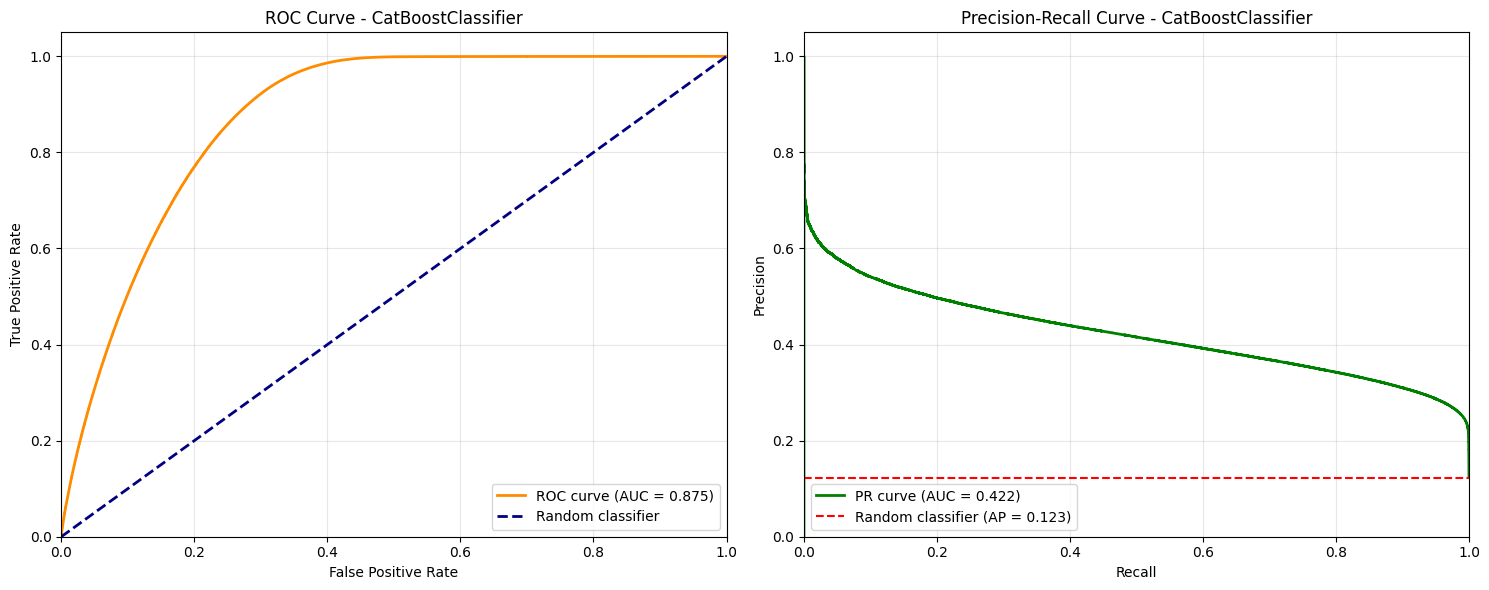

In [34]:
evaluate_model(cb_classifier, X_test, y_test, 'CatBoostClassifier', 'Test')

In [24]:
import pickle

In [25]:
with open('catboost_model_all_gpu.pkl', 'wb') as f:
    pickle.dump(cb_classifier, f)

In [26]:
files.download('./catboost_model_all_gpu.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
pred_proba = cb_classifier.predict_proba(X_test)

In [39]:
pred_test = (pred_proba[:, 1] > 0.7070707070707072).astype(int)

In [37]:
from sklearn.metrics import f1_score, precision_score, recall_score

In [41]:
print(f'Precision on test: {precision_score(y_test, pred_test):.3f}\nRecall on test: {recall_score(y_test, pred_test):.3f}\nF1 on test: {f1_score(y_test, pred_test):.3f}')

Precision on test: 0.369
Recall on test: 0.700
F1 on test: 0.483
